In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

df = pd.read_csv("../data/processed/features.csv")

df.head()

,student_id,student_name,class,section,month,fee_due,fee_paid,days_delayed,defaulted,sibling_count,transport_opted,scholarship,parent_income_band,payment_ratio,avg_delay_3m,delay_streak,total_arrears,class_section_default_rate,income_enc
0,00881816,Sara Tella,6,B,2022-01,14761,14761,7,0,0,1,0,Mid,1.0,7.000000,0,0,0.181624,2
1,00881816,Akarsh Deshmukh,6,B,2022-02,6177,6177,6,0,0,1,0,Mid,1.0,6.500000,0,0,0.181624,2
2,00881816,Baiju Jha,6,B,2022-03,3678,3678,7,0,0,1,0,Mid,1.0,6.666667,0,0,0.181624,2
3,00881816,Taimur Khare,6,B,2022-04,5140,5140,23,0,0,1,0,Mid,1.0,12.000000,0,0,0.181624,2
4,00881816,Kiara Tak,6,B,2022-05,11246,11246,5,0,0,1,0,Mid,1.0,11.666667,0,0,0.181624,2


In [2]:
print("Shape:", df.shape)

print("\nColumns:\n")
print(df.columns)

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nData Types:\n")
print(df.dtypes)

print("\nDefault Rate:")
print(df["defaulted"].mean())

Shape: (18000, 19)

Columns:

Index(['student_id', 'student_name', 'class', 'section', 'month', 'fee_due',
       'fee_paid', 'days_delayed', 'defaulted', 'sibling_count',
       'transport_opted', 'scholarship', 'parent_income_band', 'payment_ratio',
       'avg_delay_3m', 'delay_streak', 'total_arrears',
       'class_section_default_rate', 'income_enc'],
      dtype='object')

Missing Values:

student_id                    0
student_name                  0
class                         0
section                       0
month                         0
fee_due                       0
fee_paid                      0
days_delayed                  0
defaulted                     0
sibling_count                 0
transport_opted               0
scholarship                   0
parent_income_band            0
payment_ratio                 0
avg_delay_3m                  0
delay_streak                  0
total_arrears                 0
class_section_default_rate    0
income_enc              

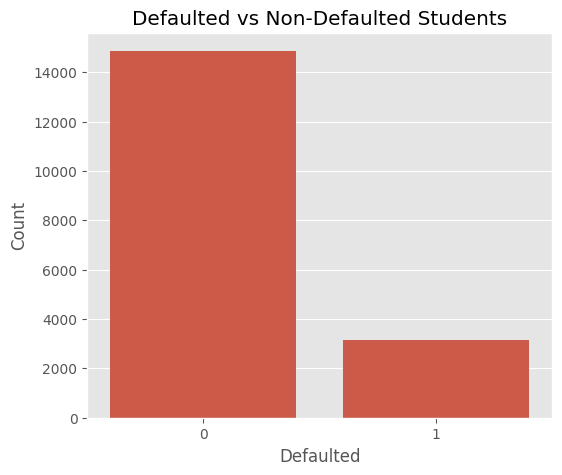

In [3]:
plt.figure(figsize=(6,5))

sns.countplot(
    x=df["defaulted"],
)

plt.title("Defaulted vs Non-Defaulted Students")
plt.xlabel("Defaulted")
plt.ylabel("Count")

plt.show()


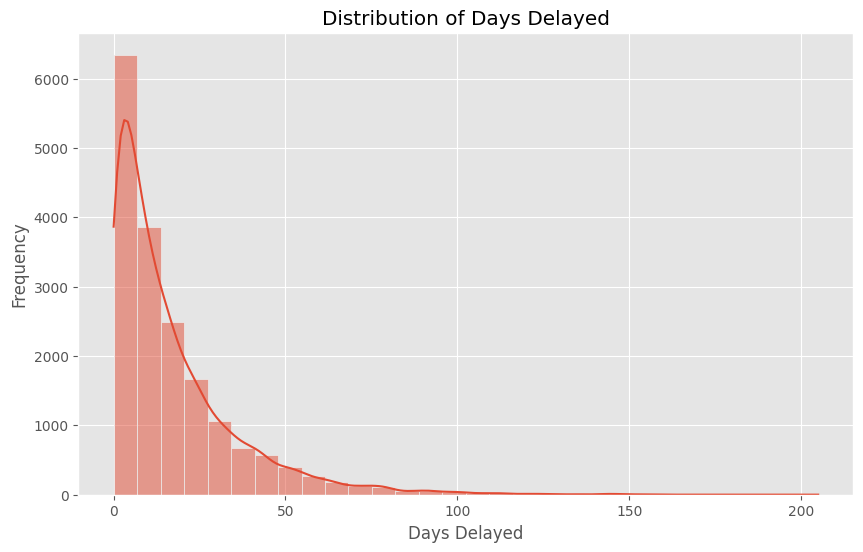

In [4]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["days_delayed"],
    bins=30,
    kde=True
)

plt.title("Distribution of Days Delayed")
plt.xlabel("Days Delayed")
plt.ylabel("Frequency")

plt.show()

### Class-wise Default Analysis

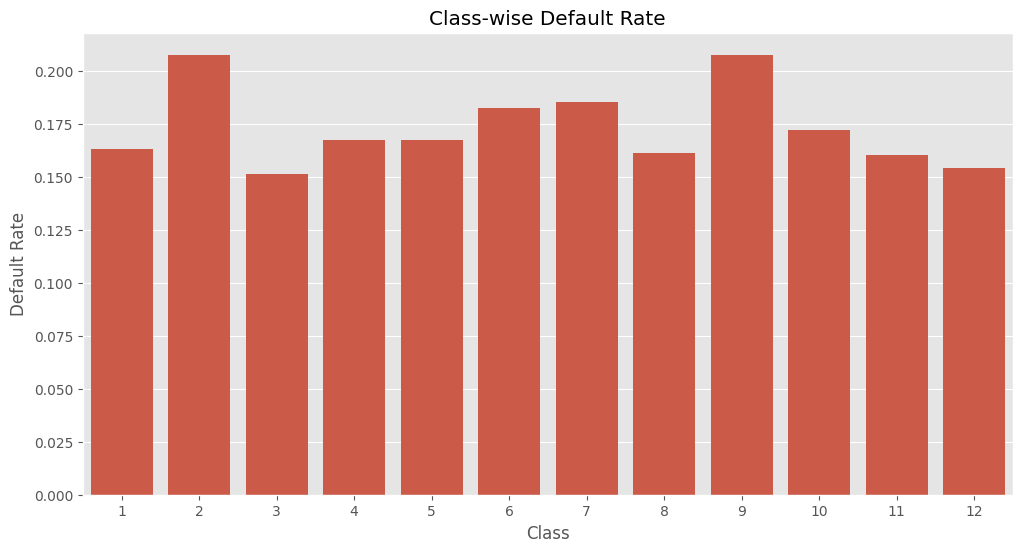

In [5]:
class_default = (
    df.groupby("class")["defaulted"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=class_default.index,
    y=class_default.values
)

plt.title("Class-wise Default Rate")
plt.xlabel("Class")
plt.ylabel("Default Rate")

plt.show()

### Income Band Risk Analysis

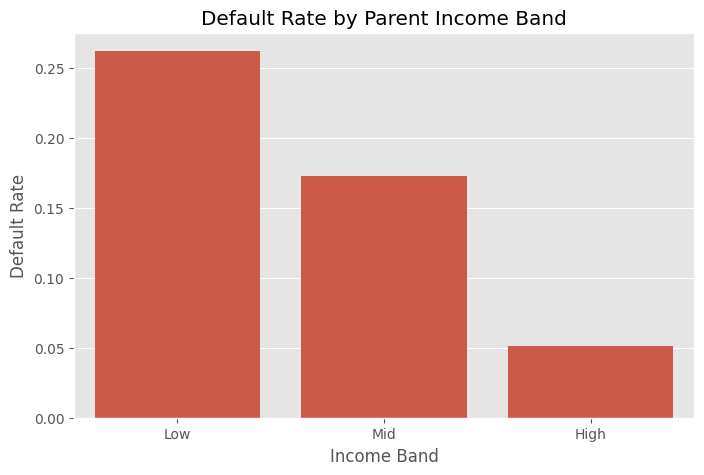

In [6]:
income_risk = (
    df.groupby("parent_income_band")["defaulted"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=income_risk.index,
    y=income_risk.values
)

plt.title("Default Rate by Parent Income Band")
plt.xlabel("Income Band")
plt.ylabel("Default Rate")

plt.show()

### correlation heatmap

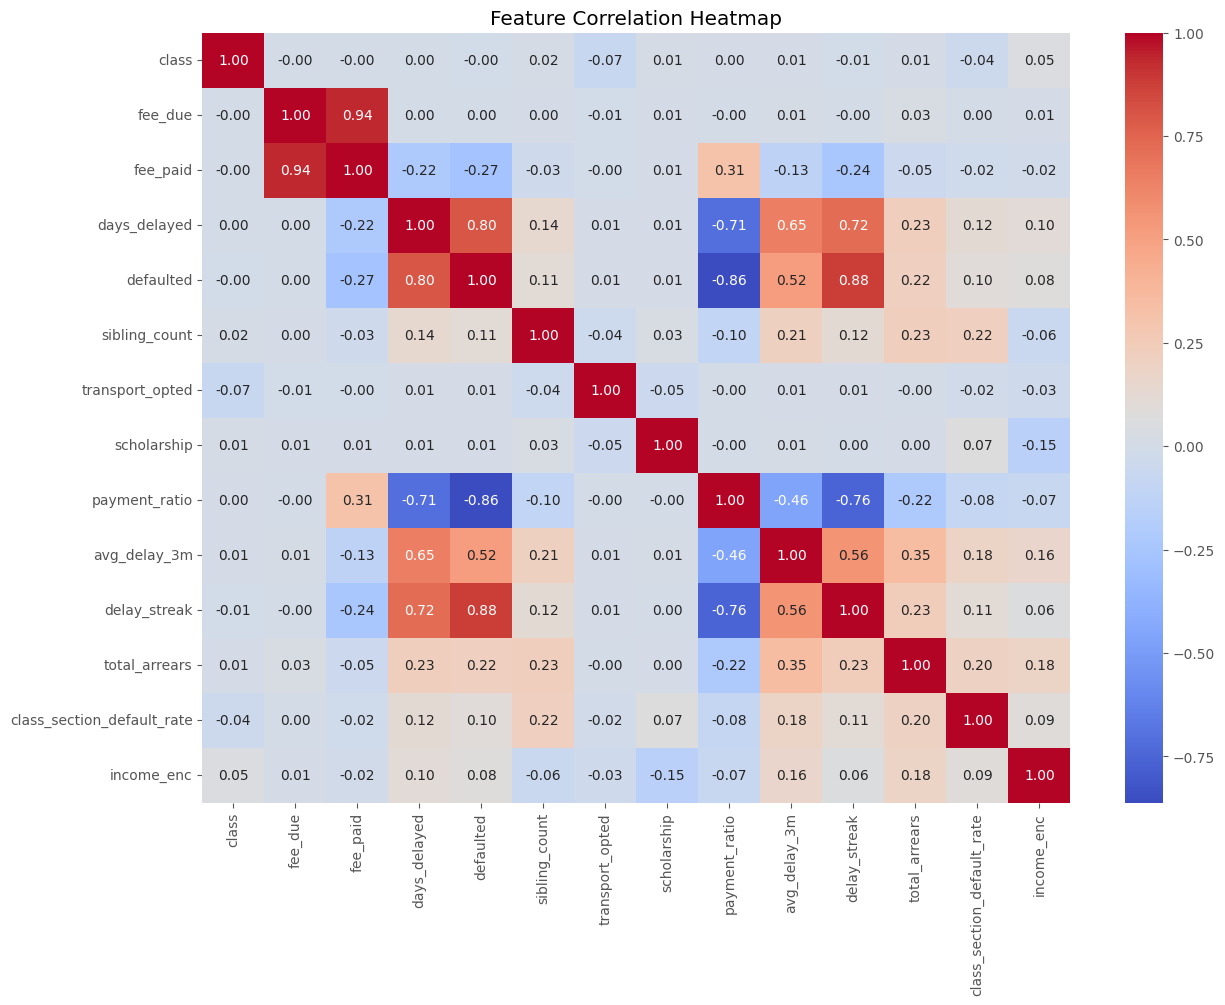

In [8]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()